In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# === Run for multiple domains (auto-select best model) ===

def select_best_model(df, y_col, candidate_models=None, significance_level=0.10):
    if candidate_models is None:
        candidate_models = ["Base", "AR", "ARX", "LagX", "AR_LagX"]
    results = []
    for mtype in candidate_models:
        try:
            data, y, X = build_model_data(df.copy(), y_col, mtype)
            y_current = data[y_col]
            X_reg = data.drop(columns=["Months", y_col])
            X_reg = sm.add_constant(X_reg, has_constant='add')

            split_idx = int(len(data) * 0.8)
            y_train, y_test = y_current[:split_idx], y_current[split_idx:]
            X_train, X_test = X_reg[:split_idx], X_reg[split_idx:]

            # fit with backward elimination
            model, X_train_sel = backward_elimination(y_train, X_train, significance_level=significance_level)

            # ensure selected training columns are unique
            X_train_sel = X_train_sel.loc[:, ~X_train_sel.columns.duplicated()]

            # prepare test matrix (unique columns) and add missing cols with zeros
            X_test_const = sm.add_constant(X_test, has_constant='add')
            X_test_const = X_test_const.loc[:, ~X_test_const.columns.duplicated()]
            missing = [c for c in X_train_sel.columns if c not in X_test_const.columns]
            for c in missing:
                X_test_const[c] = 0.0

            # align order and types to model parameters (final safety)
            X_test_sel = X_test_const.reindex(columns=X_train_sel.columns).fillna(0)
            X_test_sel = X_test_sel.reindex(columns=model.params.index).astype(float)

            # predictions and metric
            y_test_pred = model.predict(X_test_sel)
            rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

            results.append({
                "model_type": mtype,
                "rmse_test": rmse_test,
                "aic": getattr(model, "aic", np.nan),
                "bic": getattr(model, "bic", np.nan),
                "rsq": getattr(model, "rsquared", np.nan)
            })
        except Exception as e:
            results.append({"model_type": mtype, "rmse_test": np.inf, "aic": np.inf, "bic": np.inf, "rsq": np.nan, "error": str(e)})
    df_res = pd.DataFrame(results).sort_values(["rmse_test", "aic"], ascending=[True, True])
    best = df_res.iloc[0].to_dict()
    print("\nModel selection results (sorted):")
    print(df_res[["model_type","rmse_test","aic","bic","rsq"]])
    print(f"\nSelected best model: {best['model_type']} (rmse_test={best['rmse_test']:.4f}, aic={best['aic']})")
    return best["model_type"], df_res

# === Backward Elimination ===
def backward_elimination(y, X, significance_level=0.10):
    X = X.copy()
    X = X.loc[:, ~X.columns.duplicated()]
    X = sm.add_constant(X, has_constant='add')

    model = sm.OLS(y, X).fit()
    while True:
        p_values = model.pvalues
        max_pval = p_values.max()
        worst_var = p_values.idxmax()

        if max_pval <= significance_level or worst_var == "const":
            break

        print(f"Dropping '{worst_var}' (p-value = {max_pval:.4f})")
        if worst_var in X.columns:
            X = X.drop(columns=[worst_var])
        X = X.loc[:, ~X.columns.duplicated()]
        model = sm.OLS(y, X).fit()

    X = X.loc[:, ~X.columns.duplicated()]
    return model, X


# === Function: Build Model Data According to Type ===
def build_model_data(df, y_col, model_type="Base"):
    y = df[y_col]
    X = df.drop(columns=[y_col, "Months"])
    X = sm.add_constant(X, has_constant='add')

    if model_type == "Base":
        data = pd.concat([df["Months"], y, X], axis=1).dropna()

    elif model_type == "AR":
        y_lagged = y.shift(1).rename("lag_y")
        data = pd.concat([df["Months"], y, y_lagged], axis=1).dropna()

    elif model_type == "ARX":
        y_lagged = y.shift(1).rename("lag_y")
        data = pd.concat([df["Months"], y, y_lagged, X], axis=1).dropna()

    elif model_type == "LagX":
        X_lagged = X.shift(1).rename(columns=lambda c: f"lag_{c}" if c != "const" else c)
        data = pd.concat([df["Months"], y, X_lagged], axis=1).dropna()

    elif model_type == "AR_LagX":
        y_lagged = y.shift(1).rename("lag_y")
        X_lagged = X.shift(1).rename(columns=lambda c: f"lag_{c}" if c != "const" else c)
        data = pd.concat([df["Months"], y, y_lagged, X_lagged], axis=1).dropna()

    else:
        raise ValueError("Unknown model type")

    return data, y, X


# === Function: Train, Evaluate, Forecast ===
def run_ols_forecast(df, y_col, model_type="Base", n_forecast=6):
    print(f"\n{'='*40}\nProcessing domain: {y_col} | Model type: {model_type}\n{'='*40}")

    data, y, X = build_model_data(df, y_col, model_type)
    y_current = data[y_col]
    X_reg = data.drop(columns=["Months", y_col])
    X_reg = sm.add_constant(X_reg, has_constant='add')

    # --- Train/Test split (80/20) ---
    split_idx = int(len(data) * 0.8)
    y_train, y_test = y_current[:split_idx], y_current[split_idx:]
    X_train, X_test = X_reg[:split_idx], X_reg[split_idx:]
    dates_train, dates_test = data["Months"][:split_idx], data["Months"][split_idx:]

    # --- Fit model with backward elimination ---
    model, X_train_sel = backward_elimination(y_train, X_train)

    # ensure selected training columns are unique
    X_train_sel = X_train_sel.loc[:, ~X_train_sel.columns.duplicated()]

    # prepare test matrix and add missing columns with zeros
    X_test_const = sm.add_constant(X_test, has_constant='add')
    X_test_const = X_test_const.loc[:, ~X_test_const.columns.duplicated()]
    missing = [c for c in X_train_sel.columns if c not in X_test_const.columns]
    for c in missing:
        X_test_const[c] = 0

    # align columns and types with the fitted model before predicting
    X_test_sel = X_test_const.reindex(columns=X_train_sel.columns).fillna(0)
    X_test_sel = X_test_sel.reindex(columns=model.params.index).astype(float)

    # also ensure training selection is ordered like model.params and float
    X_train_sel = X_train_sel.reindex(columns=model.params.index).astype(float)

    # --- Predictions ---
    y_train_pred = model.predict(X_train_sel)
    y_test_pred = model.predict(X_test_sel)

    # --- Performance ---
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    print(f"R² (train): {model.rsquared:.4f} | Adj R²: {model.rsquared_adj:.4f}")
    print(f"RMSE (train): {rmse_train:.4f} | RMSE (test): {rmse_test:.4f}")

    # --- Forecast next n months ---
    forecast_dates = pd.date_range(start=data["Months"].iloc[-1] + pd.offsets.MonthBegin(1),
                                   periods=n_forecast, freq="MS")
    last_row = data.iloc[-1:].copy()
    current_y = y_current.iloc[-1]
    forecasts = []

    for date in forecast_dates:
        row = last_row.copy()
        if "lag_y" in X_train_sel.columns:
            row["lag_y"] = current_y
        row = row.loc[:, ~row.columns.duplicated()]
        row_input = row.reindex(columns=X_train_sel.columns).fillna(0)
        row_input = row_input.reindex(columns=model.params.index).astype(float)
        pred = float(np.asarray(model.predict(row_input)).ravel()[0])
        forecasts.append(pred)
        current_y = pred

    forecast_df = pd.DataFrame({"Months": forecast_dates, "Forecasted CPI": forecasts})

    # --- Plots ---
    plt.figure(figsize=(10, 4))
    plt.plot(dates_train, y_train, label="Actual (Train)", color="blue")
    plt.plot(dates_train, y_train_pred, label="Predicted (Train)", linestyle="--", color="cyan")
    plt.plot(dates_test, y_test, label="Actual (Test)", color="black")
    plt.plot(dates_test, y_test_pred, label="Predicted (Test)", linestyle="--", color="red")
    plt.title(f"Actual vs Predicted: {y_col}")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(data["Months"], y_current, label="Historical CPI", color="black")
    plt.plot(forecast_df["Months"], forecast_df["Forecasted CPI"], label="Forecasted CPI", color="green", marker="o")
    plt.title(f"Forecasted {y_col}")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, forecast_df


=== Processing file for Food CPI ===
  Using dependent column: 'Food CPI'
Dropping 'FAO Sugar Index' (p-value = 0.7034)
Dropping 'Subsidy_Index' (p-value = 0.5823)
Dropping 'Rice, Viet Namese 5% ($/mt)' (p-value = 0.5606)
Dropping 'Wheat, US SRW ($/mt)' (p-value = 0.5388)
Dropping 'UCSB CHIRPS Rainfall: avg' (p-value = 0.3685)
Dropping 'TradeRestriction_Index' (p-value = 0.8529)
Dropping 'Rice, Thai 25%  ($/mt)' (p-value = 0.3165)
Dropping 'Beef ** ($/kg)' (p-value = 0.2771)
Dropping 'Chicken ** ($/kg)' (p-value = 0.3462)
Dropping 'Palm kernel oil ($/mt)' (p-value = 0.9916)
Dropping 'Chicken ** ($/kg)' (p-value = 0.9804)
Dropping 'Wheat, US SRW ($/mt)' (p-value = 0.8690)
Dropping 'lag_Palm kernel oil ($/mt)' (p-value = 0.7869)
Dropping 'lag_Sugar, world ($/kg)' (p-value = 0.6094)
Dropping 'lag_Wheat, US SRW ($/mt)' (p-value = 0.5309)
Dropping 'lag_Wheat, US HRW ($/mt)' (p-value = 0.4825)
Dropping 'lag_Maize ($/mt)' (p-value = 0.5012)
Dropping 'lag_Chicken ** ($/kg)' (p-value = 0.5118)

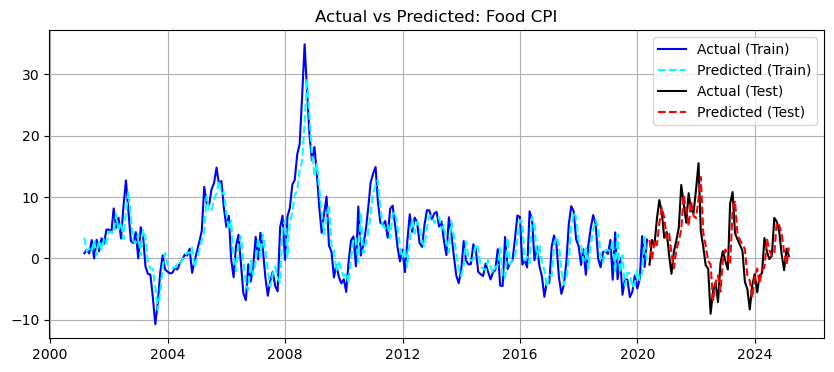

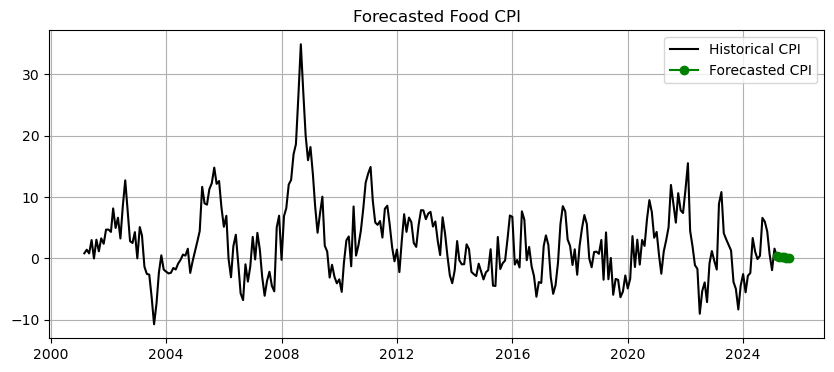


=== Processing file for Housing CPI ===
  Using dependent column: 'House CPI'
Dropping 'Crude oil, WTI ($/bbl)' (p-value = 0.6850)
Dropping 'EUR/USD' (p-value = 0.6882)
Dropping 'Crude oil, average ($/bbl)' (p-value = 0.2128)
Dropping 'Crude oil, Brent ($/bbl)' (p-value = 0.4816)
Dropping 'EUR/USD' (p-value = 0.9987)
Dropping 'Crude oil, WTI ($/bbl)' (p-value = 0.8345)
Dropping 'Crude oil, Brent ($/bbl)' (p-value = 0.3491)
Dropping 'Crude oil, average ($/bbl)' (p-value = 0.3948)
Dropping 'lag_EUR/USD' (p-value = 0.9896)
Dropping 'lag_Crude oil, WTI ($/bbl)' (p-value = 0.4571)
Dropping 'lag_Crude oil, Brent ($/bbl)' (p-value = 0.1163)
Dropping 'lag_Crude oil, average ($/bbl)' (p-value = 0.9376)
Dropping 'lag_Crude oil, WTI ($/bbl)' (p-value = 0.4978)
Dropping 'lag_Crude oil, Brent ($/bbl)' (p-value = 0.3692)
Dropping 'lag_EUR/USD' (p-value = 0.3461)
Dropping 'lag_Crude oil, average ($/bbl)' (p-value = 0.2987)

Model selection results (sorted):
  model_type  rmse_test          aic      

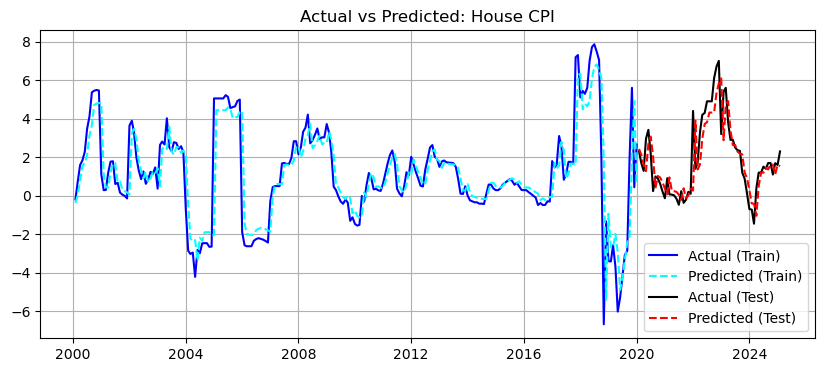

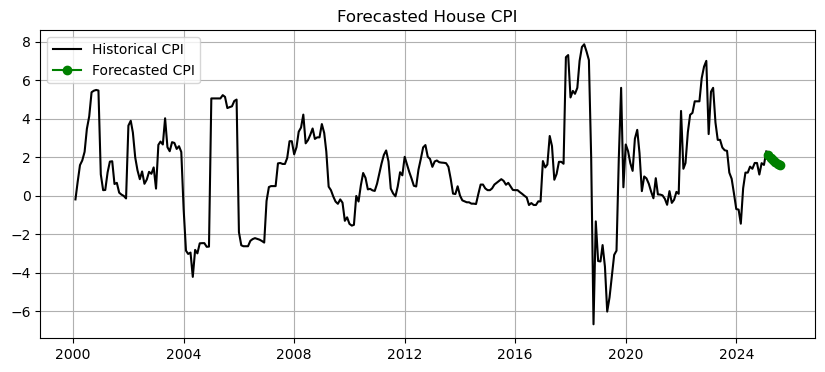


=== Processing file for Restaurant CPI ===
  Using dependent column: 'Restauration CPI'
Dropping 'Tea, Kolkata ($/kg) TEA_KOLKATA' (p-value = 0.9351)
Dropping 'Wheat, US HRW ($/mt) WHEAT_US_HRW' (p-value = 0.7735)
Dropping 'Lamb **($/kg) LAMB' (p-value = 0.6564)
Dropping 'Rice, Thai 25% ($/mt) RICE_25' (p-value = 0.7322)
Dropping 'Rice, Thai A.1 ($/mt) RICE_A1' (p-value = 0.3743)
Dropping 'Barley ($/mt) BARLEY' (p-value = 0.4149)
Dropping 'Coconut oil ($/mt) COCONUT_OIL' (p-value = 0.1962)
Dropping 'Sunflower oil ($/mt) SUNFLOWER_OIL' (p-value = 0.2147)
Dropping 'Sugar, EU ($/kg) SUGAR_EU' (p-value = 0.1573)
Dropping 'Palm oil ($/mt) PALM_OIL' (p-value = 0.9426)
Dropping 'Rice, Viet Namese 5% ($/mt) RICE_05_VNM' (p-value = 0.9223)
Dropping 'Banana, US ($/kg) BANANA_US' (p-value = 0.8728)
Dropping 'Sunflower oil ($/mt) SUNFLOWER_OIL' (p-value = 0.8593)
Dropping 'Barley ($/mt) BARLEY' (p-value = 0.8576)
Dropping 'Rice, Thai 5% ($/mt) RICE_05' (p-value = 0.8339)
Dropping 'Tea, Mombasa ($

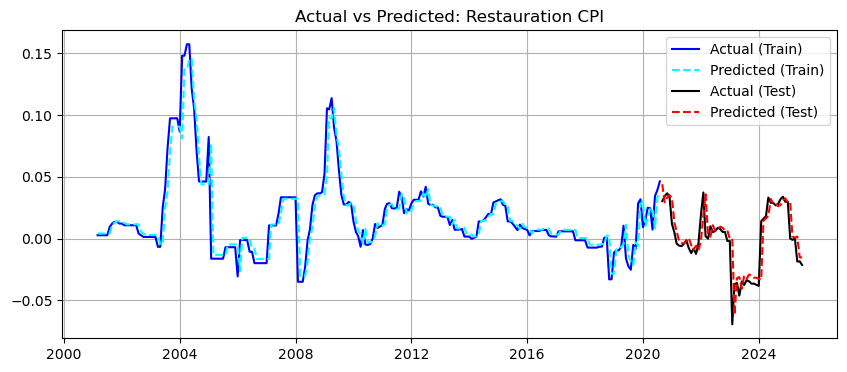

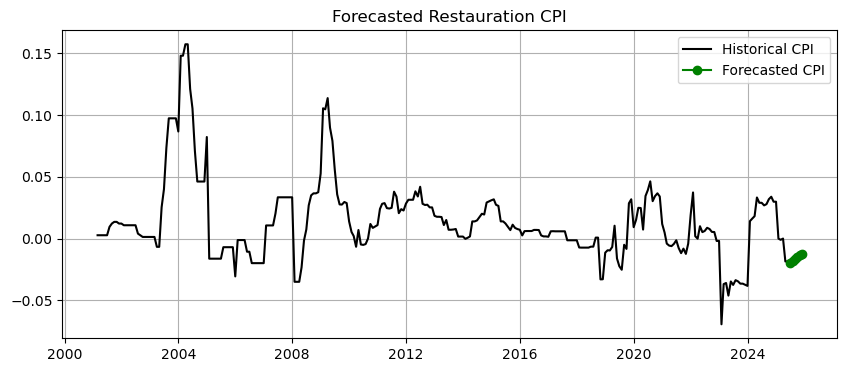


=== Processing file for Transportation CPI ===
  Using dependent column: 'transportation CPI'
Dropping 'Natural gas, US ($/mmbtu) NGAS_US' (p-value = 0.6890)
Dropping 'Liquefied natural gas, Japan ($/mmbtu) NGAS_JP' (p-value = 0.2408)
Dropping 'Coal, South African **($/mt) COAL_SAFRICA' (p-value = 0.1131)
Dropping 'Natural gas, Europe ($/mmbtu) NGAS_EUR' (p-value = 0.7660)
Dropping 'Natural gas, US ($/mmbtu) NGAS_US' (p-value = 0.3641)
Dropping 'Liquefied natural gas, Japan ($/mmbtu) NGAS_JP' (p-value = 0.3251)
Dropping 'Crude oil, Dubai ($/bbl) CRUDE_DUBAI' (p-value = 0.2336)
Dropping 'Crude oil, WTI ($/bbl) CRUDE_WTI' (p-value = 0.3135)
Dropping 'Crude oil, Brent ($/bbl) CRUDE_BRENT' (p-value = 0.6001)
Dropping 'Coal, South African **($/mt) COAL_SAFRICA' (p-value = 0.1821)
Dropping 'lag_Natural gas, US ($/mmbtu) NGAS_US' (p-value = 0.7631)
Dropping 'lag_Coal, South African **($/mt) COAL_SAFRICA' (p-value = 0.2063)
Dropping 'lag_Natural gas, US ($/mmbtu) NGAS_US' (p-value = 0.9837)
D

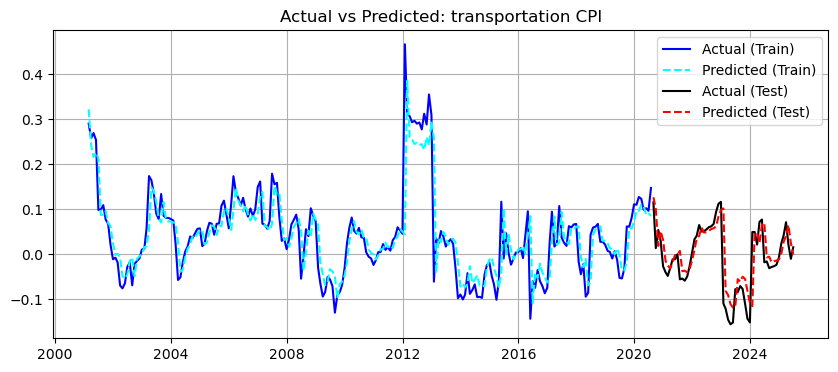

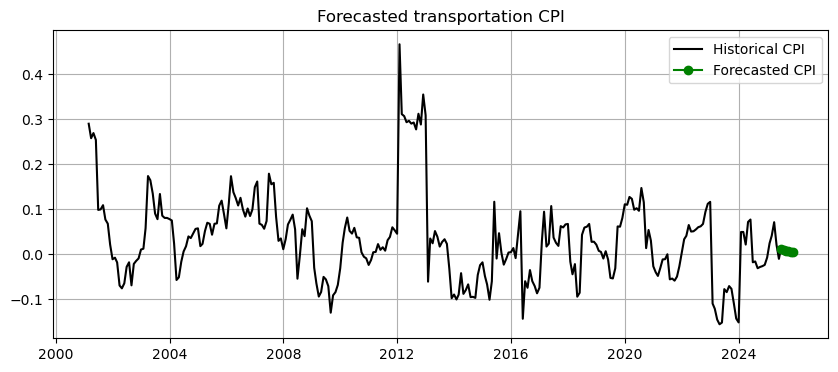

In [ ]:
# === Run for multiple domains ===
base_path = "/Users/harold/DataAnalyctisandScience/Cointegration_Johansen_test"

domain_files = {
    "Food CPI": f"{base_path}/dataFoodCPI/Benin_completes.xlsx",
    "Housing CPI": f"{base_path}/dataHousingCPI/Benin_completes.xlsx",
    "Restaurant CPI": f"{base_path}/dataRestaurantCPI/Benin_completes.xlsx",
    "Transportation CPI": f"{base_path}/dataTransportationCPI/Benin_completes.xlsx",
}

# helper: find actual y column in dataframe using simple keyword matching
def find_y_col(df, domain_label):
    keyword_map = {
        "Food CPI": ["food"],
        "Housing CPI": ["housing", "house", "rent"],
        "Restaurant CPI": ["restaur", "restaurant", "restauration"],
        "Transportation CPI": ["transport", "transportation"]
    }
    kws = keyword_map.get(domain_label, [domain_label.split()[0].lower()])
    cols = df.columns.tolist()
    for kw in kws:
        for c in cols:
            if kw.lower() in str(c).lower():
                return c
    return None

n_forecast = 6
results = {}
selection_summaries = {}

for domain_label, file_path in domain_files.items():
    print(f"\n=== Processing file for {domain_label} ===")
    df = pd.read_excel(file_path)
    df["Months"] = pd.to_datetime(df["Months"])

    # detect dependent column name present in file
    y_col = find_y_col(df, domain_label)
    if y_col is None:
        print(f"  Skipping {domain_label}: could not find dependent column. Available columns: {df.columns.tolist()}")
        continue
    print(f"  Using dependent column: '{y_col}'")

    # model selection and run
    best_model_type, summary_df = select_best_model(df, y_col, candidate_models=None)
    selection_summaries[domain_label] = summary_df
    model, forecast_df = run_ols_forecast(df, y_col, best_model_type, n_forecast)
    results[domain_label] = {"model_type": best_model_type, "model": model, "forecast": forecast_df}


In [ ]:
# print compact summary
for domain, info in results.items():
    print(f"\n{domain} -> selected model: {info['model_type']}")
    print(info["forecast"])


Food CPI -> selected model: AR
      Months  Forecasted CPI
0 2025-03-01        0.330252
1 2025-04-01        0.272665
2 2025-05-01        0.225120
3 2025-06-01        0.185866
4 2025-07-01        0.153456
5 2025-08-01        0.126698

Housing CPI -> selected model: ARX
      Months  Forecasted CPI
0 2025-03-01        2.123655
1 2025-04-01        1.974961
2 2025-05-01        1.849580
3 2025-06-01        1.743859
4 2025-07-01        1.654714
5 2025-08-01        1.579546

Restaurant CPI -> selected model: AR
      Months  Forecasted CPI
0 2025-07-01       -0.019515
1 2025-08-01       -0.017830
2 2025-09-01       -0.016291
3 2025-10-01       -0.014885
4 2025-11-01       -0.013600
5 2025-12-01       -0.012425

Transportation CPI -> selected model: AR
      Months  Forecasted CPI
0 2025-07-01        0.012810
1 2025-08-01        0.010379
2 2025-09-01        0.008410
3 2025-10-01        0.006814
4 2025-11-01        0.005521
5 2025-12-01        0.004473
